In [305]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Find project root (parent of the analysis folder)
project_root = Path.cwd().parent

# Dataset path
data_path = project_root / "Data & Resources" / "ECOMM DATA.xlsx"

# Check dataset exists
if not data_path.exists():
    raise FileNotFoundError(f"Dataset not found: {data_path}")

# Load dataset
df = pd.read_excel(data_path)

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

df.head()

c:\Users\shaur\anaconda3\Lib\site-packages\openpyxl\worksheet\_read_only.py:79: UserWarning: Unknown extension is not supported and will be removed
  for idx, row in parser.parse():


Dataset shape: (51290, 24)

Columns:
['ROW ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'City', 'State', 'Country', 'Market', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Shipping Cost', 'Profit', 'Order Priority']


,ROW ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Shipping Cost,Profit,Order Priority
0,26341,CA-2012-124891,2012-07-31,2012-07-31,Same Day,RH-19495,Rick Hansen,Consumer,New York City,New York,...,TEC-AC-10003033,Technology,Accessories,Plantronics CS510 - Over-the-Head monaural Wir...,2309.650,7,0.0,933.57,762.1845,Critical
1,26341,IN-2013-77878,2013-02-05,2013-02-07,Second Class,JR-16210,Justin Ritter,Corporate,Wollongong,New South Wales,...,FUR-CH-10003950,Furniture,Chairs,"Novimex Executive Leather Armchair, Black",3709.395,9,0.1,923.63,-288.7650,Critical
2,25330,IN-2013-71249,2013-10-17,2013-10-18,First Class,CR-12730,Craig Reiter,Consumer,Brisbane,Queensland,...,TEC-PH-10004664,Technology,Phones,"Nokia Smart Phone, with Caller ID",5175.171,9,0.1,915.49,919.9710,Medium
3,13524,ES-2013-1579342,2013-01-28,2013-01-30,First Class,KM-16375,Katherine Murray,Home Office,Berlin,Berlin,...,TEC-PH-10004583,Technology,Phones,"Motorola Smart Phone, Cordless",2892.510,5,0.1,910.16,-96.5400,Medium
4,47221,SG-2013-4320,2013-11-05,2013-11-06,Same Day,RH-9495,Rick Hansen,Consumer,Dakar,Dakar,...,TEC-SHA-10000501,Technology,Copiers,"Sharp Wireless Fax, High-Speed",2832.960,8,0.0,903.04,311.5200,Critical


In [306]:
# Check Dataset Time Range

print("Minimum Order Date:", df["Order Date"].min())
print("Maximum Order Date:", df["Order Date"].max())

print("\nOrders by Year:")
print(df["Order Date"].dt.year.value_counts().sort_index())

Minimum Order Date: 2011-01-01 00:00:00
Maximum Order Date: 2014-12-31 00:00:00

Orders by Year:
2011     8998
2012    10962
2013    13799
2014    17531
Name: Order Date, dtype: int64


In [307]:
# Temporal Prediction Setup

cutoff_date = pd.Timestamp("2014-01-01")

train_data = df[df["Order Date"] < cutoff_date].copy()
future_data = df[df["Order Date"] >= cutoff_date].copy()

print("Training period:", train_data["Order Date"].min(), "to", train_data["Order Date"].max())
print("Future period:", future_data["Order Date"].min(), "to", future_data["Order Date"].max())

print("\nTraining transactions:", len(train_data))
print("Future transactions:", len(future_data))

# Customers present in both periods
train_customers = set(train_data["Customer ID"])
future_customers = set(future_data["Customer ID"])

overlap = train_customers.intersection(future_customers)

print("\nCustomers in training period:", len(train_customers))
print("Customers in future period:", len(future_customers))
print("Customers present in both periods:", len(overlap))

Training period: 2011-01-01 00:00:00 to 2013-12-31 00:00:00
Future period: 2014-01-01 00:00:00 to 2014-12-31 00:00:00

Training transactions: 33759
Future transactions: 17531

Customers in training period: 1575
Customers in future period: 1511
Customers present in both periods: 1496


In [308]:
# Build Historical Customer Features

# Use only 2011-2013 behavior as model features
historical_features = train_data.groupby("Customer ID").agg(
    Past_Sales=("Sales", "sum"),
    Past_Profit=("Profit", "sum"),
    Past_Quantity=("Quantity", "sum"),
    Past_Orders=("Order ID", "nunique"),
    Last_Order_Date=("Order Date", "max")
)

# Recency: days since the customer's last order before 2014
historical_features["Recency_Days"] = (
    cutoff_date - historical_features["Last_Order_Date"]
).dt.days

# Keep only customers who also appear in the future period
historical_features = historical_features[
    historical_features.index.isin(overlap)
].copy()

print("Historical customer feature table shape:", historical_features.shape)
print("\nFeatures:")
print(historical_features.columns.tolist())

historical_features.head()

Historical customer feature table shape: (1496, 6)

Features:
['Past_Sales', 'Past_Profit', 'Past_Quantity', 'Past_Orders', 'Last_Order_Date', 'Recency_Days']


,Past_Sales,Past_Profit,Past_Quantity,Past_Orders,Last_Order_Date,Recency_Days
Customer ID,,,,,,
AA-10315,9858.20650,-86.53100,92,12,2013-12-31,1
AA-10375,3979.65700,2.96190,87,16,2013-12-30,2
AA-10480,9942.68278,1101.17698,105,14,2013-10-29,64
AA-10645,11804.01190,2366.19940,189,26,2013-12-20,12
AA-315,1455.86400,217.97400,16,4,2013-09-19,104


In [309]:
# Create Future Customer Value Target

# Calculate each customer's sales during 2014
future_sales = future_data.groupby("Customer ID")["Sales"].sum()

# Keep only customers used in the historical feature table
future_sales = future_sales[
    future_sales.index.isin(historical_features.index)
]

# Define high-value customers using the median of 2014 sales
sales_threshold = future_sales.median()

historical_features["Future_Sales"] = future_sales

historical_features["High_Value_Future"] = (
    historical_features["Future_Sales"] >= sales_threshold
).astype(int)

print("2014 Median Customer Sales:", round(sales_threshold, 2))

print("\nFuture Customer Classes:")
print(
    historical_features["High_Value_Future"]
    .value_counts()
    .rename(index={0: "Low Value", 1: "High Value"})
)

print("\nFinal dataset shape:", historical_features.shape)

2014 Median Customer Sales: 1976.07

Future Customer Classes:
High Value    748
Low Value     748
Name: High_Value_Future, dtype: int64

Final dataset shape: (1496, 8)


In [310]:
# Prepare Features and Target for Future Value Prediction

feature_columns = [
    "Past_Sales",
    "Past_Profit",
    "Past_Quantity",
    "Past_Orders",
    "Recency_Days"
]

X_future = historical_features[feature_columns]
y_future = historical_features["High_Value_Future"]

print("Features used for prediction:")
print(feature_columns)

print("\nFeature matrix shape:", X_future.shape)
print("Target shape:", y_future.shape)

Features used for prediction:
['Past_Sales', 'Past_Profit', 'Past_Quantity', 'Past_Orders', 'Recency_Days']

Feature matrix shape: (1496, 5)
Target shape: (1496,)


In [311]:
# Split Historical Data for Model Training

from sklearn.model_selection import train_test_split

X_train_future, X_test_future, y_train_future, y_test_future = train_test_split(
    X_future,
    y_future,
    test_size=0.2,
    random_state=42,
    stratify=y_future
)

print("Training samples:", len(X_train_future))
print("Testing samples:", len(X_test_future))

print("\nTraining class distribution:")
print(y_train_future.value_counts())

print("\nTesting class distribution:")
print(y_test_future.value_counts())

Training samples: 1196
Testing samples: 300

Training class distribution:
0    598
1    598
Name: High_Value_Future, dtype: int64

Testing class distribution:
0    150
1    150
Name: High_Value_Future, dtype: int64


In [312]:
# Train Future Value Prediction Model

from sklearn.ensemble import RandomForestClassifier

future_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

future_model.fit(X_train_future, y_train_future)

# Predictions
y_pred_future = future_model.predict(X_test_future)

print("Future Value Prediction Model trained successfully.")


Future Value Prediction Model trained successfully.


In [313]:
# Evaluate Future Value Prediction Model

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

accuracy_future = accuracy_score(y_test_future, y_pred_future)
precision_future = precision_score(y_test_future, y_pred_future)
recall_future = recall_score(y_test_future, y_pred_future)
f1_future = f1_score(y_test_future, y_pred_future)

print("Future Value Prediction Performance")
print("-----------------------------------")
print(f"Accuracy : {accuracy_future:.4f}")
print(f"Precision: {precision_future:.4f}")
print(f"Recall   : {recall_future:.4f}")
print(f"F1 Score : {f1_future:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test_future,
        y_pred_future,
        target_names=["Low Value", "High Value"]
    )
)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_future, y_pred_future))

Future Value Prediction Performance
-----------------------------------
Accuracy : 0.8633
Precision: 0.8658
Recall   : 0.8600
F1 Score : 0.8629

Classification Report:
              precision    recall  f1-score   support

   Low Value       0.86      0.87      0.86       150
  High Value       0.87      0.86      0.86       150

    accuracy                           0.86       300
   macro avg       0.86      0.86      0.86       300
weighted avg       0.86      0.86      0.86       300


Confusion Matrix:
[[130  20]
 [ 21 129]]


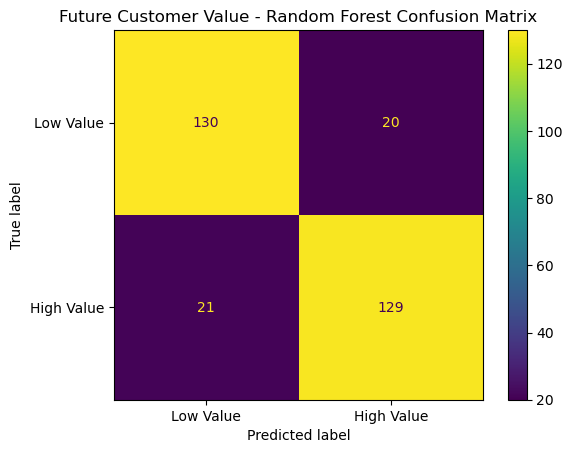

In [341]:
# Visual Confusion Matrix
cm_future = confusion_matrix(y_test_future, y_pred_future)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_future,
    display_labels=["Low Value", "High Value"]
)

disp.plot()
plt.title("Future Customer Value - Random Forest Confusion Matrix")
plt.savefig(
    "../images/future_value_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [314]:
# ROC-AUC Evaluation

from sklearn.metrics import roc_auc_score

y_prob_future = future_model.predict_proba(X_test_future)[:, 1]

roc_auc_future = roc_auc_score(
    y_test_future,
    y_prob_future
)

print("ROC-AUC Score:", round(roc_auc_future, 4))

ROC-AUC Score: 0.8669


Future Value Prediction Feature Importance:
         Feature  Importance
2  Past_Quantity      0.3371
3    Past_Orders      0.2322
0     Past_Sales      0.1983
1    Past_Profit      0.1368
4   Recency_Days      0.0956


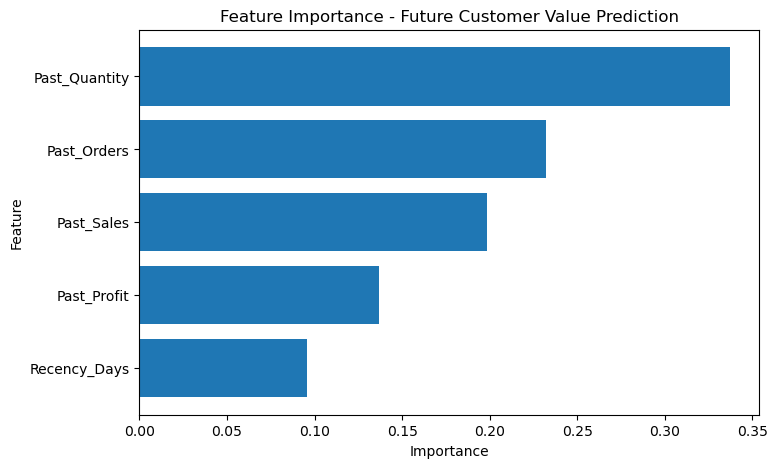

In [343]:
# Future Value Prediction - Feature Importance

future_feature_importance = pd.DataFrame({
    "Feature": X_future.columns,
    "Importance": future_model.feature_importances_
}).sort_values("Importance", ascending=False)

print("Future Value Prediction Feature Importance:")
print(future_feature_importance.round(4))

plt.figure(figsize=(8, 5))

plt.barh(
    future_feature_importance["Feature"],
    future_feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importance - Future Customer Value Prediction")
plt.gca().invert_yaxis()

plt.savefig(
    "../images/future_value_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [316]:
# Cross-Validation on Training Data Only

from sklearn.model_selection import StratifiedKFold, cross_val_score

future_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

future_cv_scores = cross_val_score(
    future_model,
    X_train_future,
    y_train_future,
    cv=future_cv,
    scoring="f1"
)

print("5-Fold Cross-Validation F1 Scores:")
print(future_cv_scores.round(4))

print("\nMean CV F1 Score:", round(future_cv_scores.mean(), 4))
print("Standard Deviation:", round(future_cv_scores.std(), 4))

5-Fold Cross-Validation F1 Scores:
[0.8148 0.8571 0.8835 0.8455 0.8739]

Mean CV F1 Score: 0.855
Standard Deviation: 0.024


### Temporal Validation Results

The model was trained using customer behavior from 2011–2013 and
evaluated against customer sales outcomes in 2014.

A stratified 5-fold cross-validation was performed on the training
data only, producing a mean F1 score of **0.8550** with a standard
deviation of **0.0240**.

On the untouched 2014 test set, the model achieved an F1 score of
**0.8629** and a ROC-AUC of **0.8669**.

The similar cross-validation and held-out test performance suggests
that the model generalizes reasonably well to unseen customer outcomes.

### Business Impact of Prediction Errors

The model's errors have different business implications:

- **False Negative:** A customer who becomes high-value in 2014 is
  predicted as low-value. This could cause the business to miss
  retention, loyalty, or personalized marketing opportunities.

- **False Positive:** A customer who is not high-value in 2014 is
  predicted as high-value. This could result in marketing resources
  being allocated to a lower-value customer.

For customer retention campaigns, false negatives may be particularly
important because failing to identify a valuable customer can result in
a missed opportunity to retain or engage them.

The model achieved a **0.8669 ROC-AUC**, indicating good ability to
distinguish between future high-value and low-value customers.

The appropriate classification threshold would ultimately depend on
the business cost of false positives versus false negatives.

In [317]:
# RFM-Based Customer Segmentation

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# RFM features from 2011-2013
rfm_features = historical_features[
    ["Recency_Days", "Past_Orders", "Past_Sales"]
].copy()

# Scale features
rfm_scaler = StandardScaler()
rfm_scaled = rfm_scaler.fit_transform(rfm_features)

# Evaluate different numbers of clusters
silhouette_scores_rfm = {}

for k in range(2, 7):
    kmeans_rfm = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = kmeans_rfm.fit_predict(rfm_scaled)
    score = silhouette_score(rfm_scaled, labels)
    silhouette_scores_rfm[k] = score

print("RFM Segmentation Silhouette Scores:")

for k, score in silhouette_scores_rfm.items():
    print(f"K={k}: {score:.4f}")

best_k_rfm = max(
    silhouette_scores_rfm,
    key=silhouette_scores_rfm.get
)

print(f"\nBest K: {best_k_rfm}")
print(f"Best Silhouette Score: {silhouette_scores_rfm[best_k_rfm]:.4f}")

c:\Users\shaur\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(
c:\Users\shaur\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(
c:\Users\shaur\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(
c:\Users\shaur\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Window

RFM Segmentation Silhouette Scores:
K=2: 0.5306
K=3: 0.5366
K=4: 0.4604
K=5: 0.4148
K=6: 0.3847

Best K: 3
Best Silhouette Score: 0.5366


In [318]:
# Create Final RFM Customer Segments

final_rfm_kmeans = KMeans(
    n_clusters=best_k_rfm,
    random_state=42,
    n_init=10
)

historical_features["RFM_Cluster"] = final_rfm_kmeans.fit_predict(
    rfm_scaled
)

# Summarize the segments
rfm_cluster_summary = historical_features.groupby("RFM_Cluster").agg({
    "Recency_Days": "mean",
    "Past_Orders": "mean",
    "Past_Sales": "mean",
    "Past_Profit": "mean"
}).round(2)

print("RFM Customer Segment Summary:")
print(rfm_cluster_summary)

c:\Users\shaur\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(


RFM Customer Segment Summary:
             Recency_Days  Past_Orders  Past_Sales  Past_Profit
RFM_Cluster                                                    
0                   36.82        17.83     9659.94      1166.46
1                  101.06         5.15     1729.73       152.63
2                  494.44         2.77      952.15       105.57


In [319]:
# Assign Business-Friendly Segment Labels

segment_labels = {
    0: "High-Value Loyal",
    1: "Mid-Value / Developing",
    2: "Inactive / At-Risk"
}

historical_features["Customer_Segment"] = (
    historical_features["RFM_Cluster"].map(segment_labels)
)

print("Customer Segment Distribution:")
print(historical_features["Customer_Segment"].value_counts())

print("\nSegment Summary:")
print(
    historical_features.groupby("Customer_Segment")[
        ["Recency_Days", "Past_Orders", "Past_Sales", "Past_Profit"]
    ].mean().round(2)
)

Customer Segment Distribution:
High-Value Loyal          726
Mid-Value / Developing    626
Inactive / At-Risk        144
Name: Customer_Segment, dtype: int64

Segment Summary:
                        Recency_Days  Past_Orders  Past_Sales  Past_Profit
Customer_Segment                                                          
High-Value Loyal               36.82        17.83     9659.94      1166.46
Inactive / At-Risk            494.44         2.77      952.15       105.57
Mid-Value / Developing        101.06         5.15     1729.73       152.63


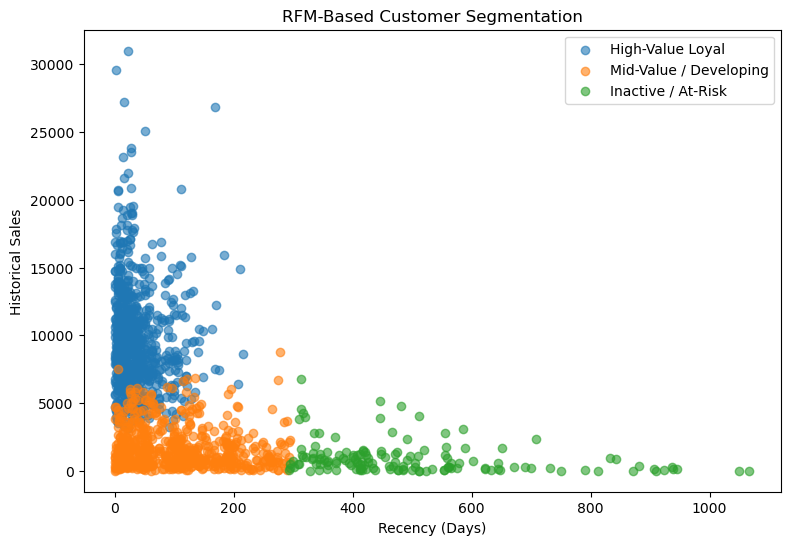

In [342]:
# RFM Customer Segment Visualization

plt.figure(figsize=(9, 6))

for segment in historical_features["Customer_Segment"].unique():
    segment_data = historical_features[
        historical_features["Customer_Segment"] == segment
    ]

    plt.scatter(
        segment_data["Recency_Days"],
        segment_data["Past_Sales"],
        label=segment,
        alpha=0.6
    )

plt.xlabel("Recency (Days)")
plt.ylabel("Historical Sales")
plt.title("RFM-Based Customer Segmentation")
plt.legend()
plt.savefig("../images/rfm_segmentation.png", dpi=300, bbox_inches="tight")
plt.show()

### RFM Segmentation Insights

RFM-based K-Means clustering was used to segment customers using
historical behavior from 2011–2013.

The Silhouette Score was evaluated for K=2 through K=6. The best
result was obtained with **K=3 (0.5366)**.

The resulting segments were:

- **High-Value Loyal (726 customers):** recent purchases, high order
  frequency, and substantially higher historical sales and profit.
- **Mid-Value / Developing (626 customers):** moderate purchase
  frequency, spending, and recency.
- **Inactive / At-Risk (144 customers):** low purchase frequency,
  relatively low historical spending, and much longer time since the
  last purchase.

Compared with the original sales-based clustering, the RFM approach
provides more behaviorally meaningful segments that can directly
support customer retention and targeted marketing strategies.

In [321]:
print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())


print("\nData types:")
print(df.dtypes)

Missing values:
ROW ID                0
Order ID              0
Order Date            0
Ship Date             0
Ship Mode             0
Customer ID           0
Customer Name         0
Segment               0
City                  0
State                 0
Country               0
Market                0
Postal Code       41296
Region                0
Product ID            0
Category              0
Sub-Category          0
Product Name          0
Sales                 0
Quantity              0
Discount              0
Shipping Cost         0
Profit                0
Order Priority        0
dtype: int64

Duplicate rows: 0

Data types:
ROW ID                     int64
Order ID                  object
Order Date        datetime64[ns]
Ship Date         datetime64[ns]
Ship Mode                 object
Customer ID               object
Customer Name             object
Segment                   object
City                      object
State                     object
Country                   object


In [322]:
print("Duplicate rows:", df.duplicated().sum())

print("\nDate columns:")
print(df[["Order Date", "Ship Date"]].dtypes)

print("\nUnique values:")
print("Customers:", df["Customer ID"].nunique())
print("Products:", df["Product ID"].nunique())
print("Categories:", df["Category"].nunique())
print("Regions:", df["Region"].nunique())

Duplicate rows: 0

Date columns:
Order Date    datetime64[ns]
Ship Date     datetime64[ns]
dtype: object

Unique values:
Customers: 1590
Products: 10292
Categories: 3
Regions: 13


In [323]:
# Basic business metrics

print("Total Sales:", df["Sales"].sum())
print("Total Profit:", df["Profit"].sum())
print("Total Quantity:", df["Quantity"].sum())
print("Average Order Value:", df["Sales"].mean())
print("Average Profit per Order:", df["Profit"].mean())

print("\nSales by Category:")
print(df.groupby("Category")["Sales"].sum().sort_values(ascending=False))

print("\nProfit by Category:")
print(df.groupby("Category")["Profit"].sum().sort_values(ascending=False))

Total Sales: 12642501.909880001
Total Profit: 1467457.29128
Total Quantity: 178312
Average Order Value: 246.49058120257362
Average Profit per Order: 28.61098247767596

Sales by Category:
Category
Technology         4.744557e+06
Furniture          4.110874e+06
Office Supplies    3.787070e+06
Name: Sales, dtype: float64

Profit by Category:
Category
Technology         663778.73318
Office Supplies    518473.83430
Furniture          285204.72380
Name: Profit, dtype: float64


In [324]:
# Monthly sales and profit trend

df["Order Date"] = pd.to_datetime(df["Order Date"])

monthly = (
    df.groupby(df["Order Date"].dt.to_period("M"))
      .agg(
          Sales=("Sales", "sum"),
          Profit=("Profit", "sum")
      )
      .reset_index()
)

monthly["Order Date"] = monthly["Order Date"].dt.to_timestamp()

print(monthly.head(10))

  Order Date         Sales       Profit
0 2011-01-01   98898.48886   8321.80096
1 2011-02-01   91152.15698  12417.90698
2 2011-03-01  145729.36736  15303.56826
3 2011-04-01  116915.76418  12902.32438
4 2011-05-01  146747.83610  12183.82870
5 2011-06-01  215207.38022  23415.24702
6 2011-07-01  115510.41912   5585.00352
7 2011-08-01  207581.49122  23713.66772
8 2011-09-01  290214.45534  35776.88394
9 2011-10-01  199071.26404  25963.41834


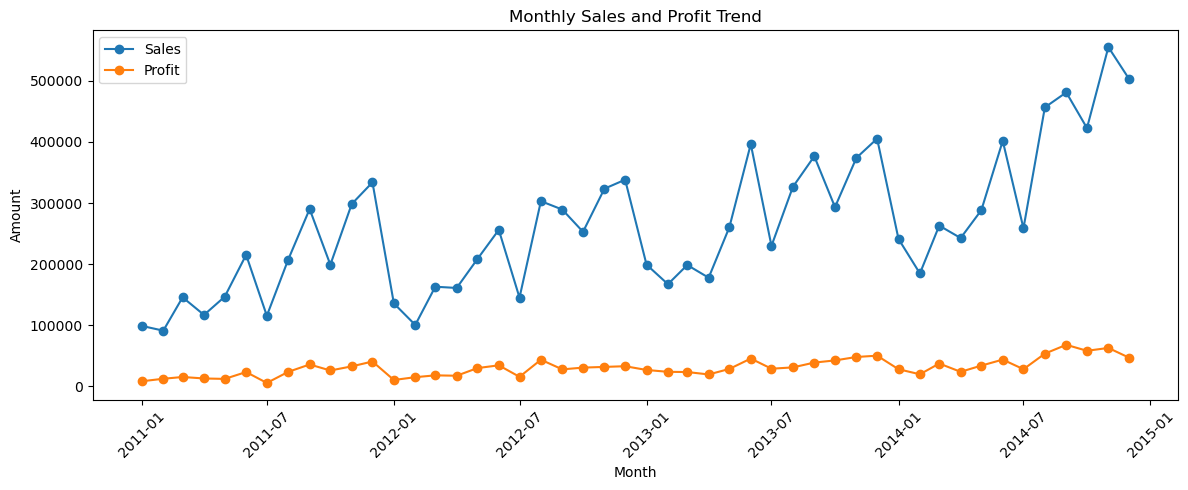

In [325]:
# Monthly Sales and Profit Trend

plt.figure(figsize=(12, 5))

plt.plot(
    monthly["Order Date"],
    monthly["Sales"],
    marker="o",
    label="Sales"
)

plt.plot(
    monthly["Order Date"],
    monthly["Profit"],
    marker="o",
    label="Profit"
)

plt.title("Monthly Sales and Profit Trend")
plt.xlabel("Month")
plt.ylabel("Amount")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [326]:
# Top 10 products by profit

top_products = (
    df.groupby("Product Name")
      .agg(
          Sales=("Sales", "sum"),
          Profit=("Profit", "sum"),
          Quantity=("Quantity", "sum")
      )
      .sort_values("Profit", ascending=False)
      .head(10)
)

print(top_products)

                                                         Sales      Profit  \
Product Name                                                                 
Canon imageCLASS 2200 Advanced Copier               61599.8240  25199.9280   
Cisco Smart Phone, Full Size                        76441.5306  17238.5206   
Motorola Smart Phone, Full Size                     73156.3030  17027.1130   
Hoover Stove, Red                                   31663.7790  11807.9690   
Sauder Classic Bookcase, Traditional                39108.3030  10672.0730   
Harbour Creations Executive Leather Armchair, A...  50121.5160  10427.3260   
Nokia Smart Phone, Full Size                        71904.5555   9938.1955   
Cisco Smart Phone, with Caller ID                   43127.5008   9786.6408   
Nokia Smart Phone, with Caller ID                   47877.7857   9465.3257   
Belkin Router, USB                                  23470.4080   8955.0180   

                                                    Quantity  


In [327]:
# Customer-level sales and profitability analysis

customer_analysis = (
    df.groupby("Customer ID")
      .agg(
          Total_Sales=("Sales", "sum"),
          Total_Profit=("Profit", "sum"),
          Total_Quantity=("Quantity", "sum"),
          Number_of_Orders=("Order ID", "nunique")
      )
      .sort_values("Total_Sales", ascending=False)
)

print("Top 10 Customers by Sales:")
print(customer_analysis.head(10))

print("\nTop 10 Customers by Profit:")
print(
    customer_analysis
    .sort_values("Total_Profit", ascending=False)
    .head(10)
)

Top 10 Customers by Sales:
             Total_Sales  Total_Profit  Total_Quantity  Number_of_Orders
Customer ID                                                             
TA-21385     35668.12080    6274.98910             239                25
GT-14710     34471.89028    5164.84718             284                30
TC-20980     34218.26900    8787.47490             209                28
SM-20320     31125.29496   -1083.67434             139                21
BW-11110     30613.61650    3337.46590             316                35
HL-15040     29664.23058    7657.50178             199                20
SE-20110     29532.62502    5863.62392             286                36
PS-19045     29252.31940    4426.19510             259                26
RB-19360     29197.63460    8523.95150             248                25
ZC-21910     28472.81926     452.50326             333                37

Top 10 Customers by Profit:
             Total_Sales  Total_Profit  Total_Quantity  Number_of_Or

# Final Project Summary

## Key Findings

- Analyzed **51,290 e-commerce transactions** across **1,590 customers** and **10,292 products**.
- Technology generated the highest overall sales and profit among the three product categories.
- Customer-level analysis identified substantial differences in purchasing behavior and profitability.
- K-Means clustering produced **2 customer segments**, with the best Silhouette Score of **0.632**.
- The two segments were interpreted as **high-value** and **low-value customers** based on average sales, profit, quantity, and order frequency.
- A Random Forest classifier was developed to identify high-value customers using customer purchasing behavior.
- The classifier achieved **96.86% accuracy** on the held-out test set.
- **Total Quantity** and **Number of Orders** were the two most important features in the classification model.

## Business Recommendations

1. **Retain high-value customers** through loyalty programs and personalized offers.
2. **Increase engagement with low-value customers** through targeted promotions and cross-selling.
3. Use **order frequency and purchase volume** as important signals for customer targeting.
4. Use customer segmentation and classification to support **data-driven marketing and retention strategies**.

## Conclusion

This project demonstrates an end-to-end data science workflow, from data cleaning and exploratory analysis to customer segmentation and supervised machine learning. The analysis converts transactional e-commerce data into actionable customer insights that can support marketing, retention, and customer-value decisions.